In [1]:
# Standard imports for data science.
import numpy as np                          # For handling the image as a numerical grid (matrix)
import matplotlib.pyplot as plt             # For plotting and visualizing our results

# skimage (scikit-image) is the go-to library for traditional image processing in Python.
from skimage import data                    # Contains standard "toy" datasets like 'coins'
from skimage.filters import threshold_otsu  # An algorithm to separate foreground from background
from skimage.segmentation import watershed  # Separates objects by treating pixel values like a map
from skimage.feature import peak_local_max  # Finds the "center" of objects in a distance map

# scipy.ndimage provides tools for processing N-dimensional arrays (images).
from scipy import ndimage as ndi

# sklearn (scikit-learn) is the main library for Machine Learning in Python.
from sklearn.cluster import KMeans          # A clustering algorithm that groups similar pixels together

# Type hinting imports: these help developers know what kind of objects variables are.
from matplotlib.figure import Figure
from numpy import ndarray

In [2]:
def get_axes_for_figure(nrows: int, ncols: int, fig_size: tuple[int, int]) -> tuple[Figure, np.ndarray]:
    """
    A helper function to create a "canvas" (Figure) with multiple "plots" (Axes).
    This keeps the main code clean.
    """
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=fig_size)
    # .ravel() converts a 2D grid of axes into a 1D list so we can use ax[0], ax[1], etc.
    return fig, axes.ravel()

## 1. Load and Explore

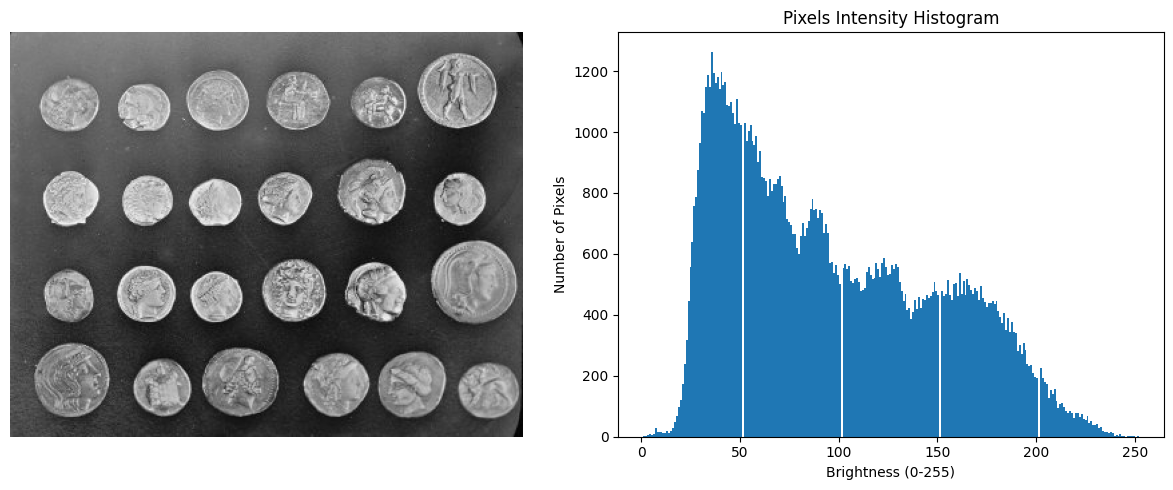

In [4]:
# Load the 'coins' image. In grayscale, a pixel is just a number from 0 (black) to 255 (white).
image: ndarray[int] = data.coins()

# We use a histogram to see the distribution of brightness. 
# Usually, we see two "humps": one for the dark background and one for the light coins.
fig, ax = get_axes_for_figure(nrows=1, ncols=2, fig_size=(12,5))
ax[0].imshow(image, cmap=plt.cm.grey)
ax[0].axis("off")

# .ravel() "flattens" the 2D image into a 1D list of all pixel values.
ax[1].hist(image.ravel(), bins=256)
ax[1].set_title("Pixels Intensity Histogram")
ax[1].set_xlabel("Brightness (0-255)")
ax[1].set_ylabel("Number of Pixels")
plt.tight_layout()
plt.show()

## 2. Simple Binarization

In [5]:
# threshold_otsu finds the best value to split the histogram into 'Background' and 'Coins'.
threshold: float = threshold_otsu(image=image)
# Create a 'mask': True if the pixel is brighter than the threshold, False otherwise.
binary_mask: ndarray[bool] = image > threshold
print(f"Calculated Otsu Threshold: {threshold}")

Calculated Otsu Threshold: 107


## 3. Preparing Watershed

In [6]:
# The 'Distance Transform' calculates for every white pixel how far it is from the background.
# The center of a coin will be "far" from the edge, so it gets a high value.
distance: ndarray[float] = ndi.distance_transform_edt(input=binary_mask)

# We find the 'peaks' in that distance map. These peaks are the centers of each coin.
coords: ndarray = peak_local_max(image=distance, footprint=np.ones((3,3)), labels=binary_mask)

# We create a blank 'mask' of zeros and place a single dot (True) at every peak coordinate.
mask = np.zeros(shape=distance.shape, dtype=bool)
mask[tuple(coords.T)] = True

# ndi.label gives each separate dot its own unique number (1, 2, 3...). 
# These are our 'seeds' or 'markers'.
markers, _ = ndi.label(mask)

## 4. Running Watershed

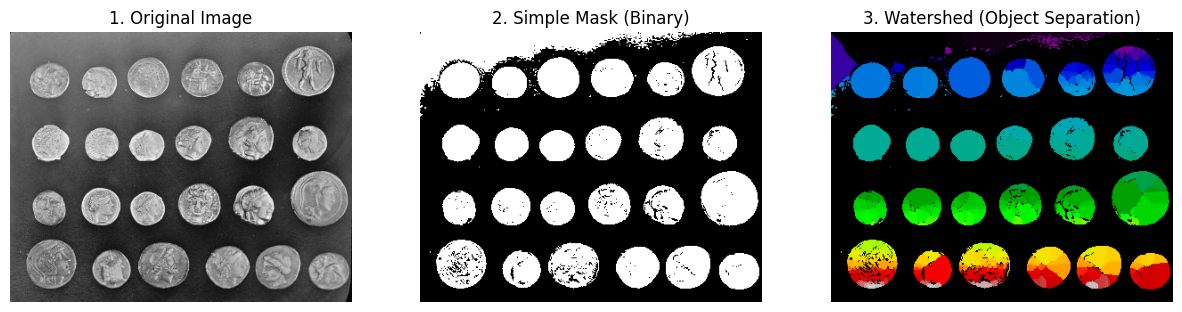

In [7]:
# Think of the distance map as a mountain range. Watershed "floods" these mountains 
# starting from our markers. When the water from two markers meets, a boundary is created.
# This is how we separate coins that are touching!
labels: ndarray[float] = watershed(image=-distance, markers=markers, mask=binary_mask)

# Visualize Watershed results
fig, ax = get_axes_for_figure(nrows=1, ncols=3, fig_size=(15,4))
ax[0].imshow(image, cmap=plt.cm.gray)
ax[0].set_title("1. Original Image")
ax[1].imshow(binary_mask, cmap=plt.cm.gray)
ax[1].set_title("2. Simple Mask (Binary)")
ax[2].imshow(labels, cmap=plt.cm.nipy_spectral) # Different colors for different coins
ax[2].set_title("3. Watershed (Object Separation)")
for a in ax:
    a.axis("off")
plt.show()

## 5. K-Means Clustering (Alternative approach)

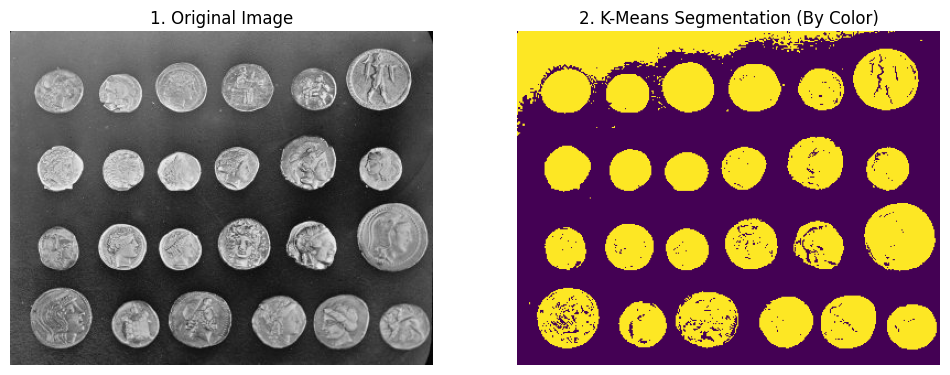

In [8]:
# Instead of looking at shapes, K-Means looks at raw pixel colors/intensities.
# It tries to group pixels into 'K' clusters (in this case, 2: foreground and background).

# We must reshape the 2D image into a single column of values for the ML model.
pixels: ndarray[int, int] = image.flatten().reshape(-1, 1)

# Initialize K-Means to find 2 groups. .fit() is where the "learning" happens.
kmeans: KMeans = KMeans(n_clusters=2, random_state=42, n_init="auto").fit(pixels)

# Get the results (which pixel belongs to which cluster) and reshape back to the image size.
segmented_labels: ndarray[int, int] = kmeans.labels_
segmented_image: ndarray[int, int] = segmented_labels.reshape(image.shape)

# Visualize K-Means results
fig, ax = get_axes_for_figure(nrows=1, ncols=2, fig_size=(12,5))
ax[0].imshow(image, cmap=plt.cm.gray)
ax[0].set_title("1. Original Image")
ax[1].imshow(segmented_image, cmap=plt.cm.viridis)
ax[1].set_title("2. K-Means Segmentation (By Color)")
ax[0].axis("off")
ax[1].axis("off")
plt.show()